# Activity 1.3

Clase: Viernes 06 de Febrero 2026

El Averaged Shifted Histogram (ASH) es un método no paramétrico para la estimación de la función de densidad que reduce la sensibilidad del histograma clásico al origen de los bins. El método construye múltiples histogramas con pequeños corrimientos en el origen y promedia sus conteos, obteniendo así una estimación más suave de la densidad.

**Idea:**
Un histograma normal depende mucho de:

* Dónde empieza el primer bin (x₀)

* El ancho de los bins

 Si movemos ligeramente el origen del histograma, la forma cambia.

**Funcionamiento del ASH**

**1.-** Construye muchos histogramas

**2.-** Cada uno empieza con un corrimiento pequeño de x₀

**3.-** Promedia todos los histogramas

**4.-** El resultado es una estimación suave de la densidad

Es como un punto medio entre:

* histograma clásico (tosco)

* KDE (muy suave)

## ¿Qué hace lafunción de ASH?

1.- Calcula el ancho del bin
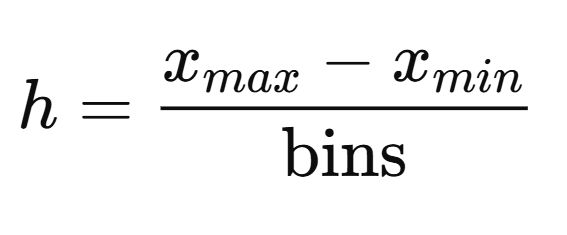

2.-Para cada corrimiento $k$

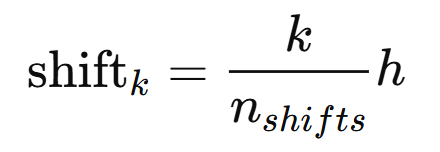

3.- Construye un histograma con bins desplazados

4.- Suma todos los histogramas

5.- Normaliza → densidad:

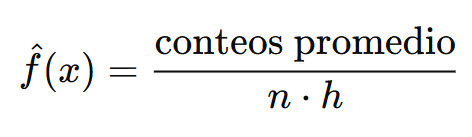

In [19]:
import numpy as np

def averaged_shifted_histogram(x, bins=20, n_shifts=20):
    """
    Estimación de densidad por Averaged Shifted Histogram (ASH)
    """
    x = np.asarray(x)
    xmin, xmax = x.min(), x.max()
    h = (xmax - xmin) / bins

    ash = np.zeros(bins)

    for k in range(n_shifts):
        shift = k * h / n_shifts
        edges = xmin + shift + np.arange(bins + 1) * h
        hist, _ = np.histogram(x, bins=edges)
        ash += hist

    ash /= (n_shifts * len(x) * h)
    centers = xmin + (np.arange(bins) + 0.5) * h

    return centers, ash


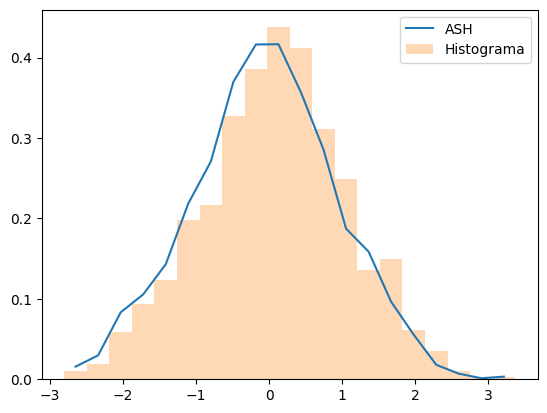

In [20]:
import matplotlib.pyplot as plt

x = np.random.normal(0, 1, 1000)

centers, density = averaged_shifted_histogram(x)

plt.plot(centers, density, label="ASH")
plt.hist(x, bins=20, density=True, alpha=0.3, label="Histograma")
plt.legend()
plt.show()


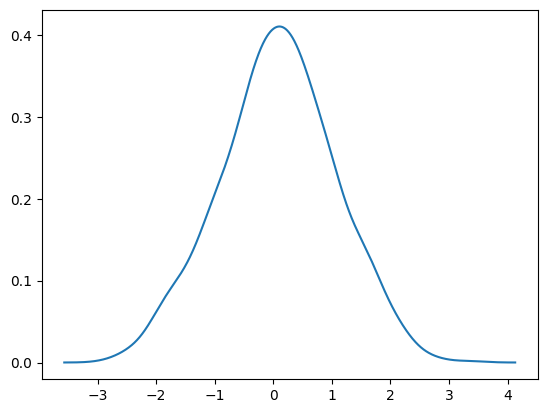

In [21]:
#En statsmodels existe ASH de forma indirecta:
from statsmodels.nonparametric.kde import KDEUnivariate

kde = KDEUnivariate(x)
kde.fit(kernel="gau", bw="scott")

plt.plot(kde.support, kde.density, label="KDE (referencia)")
